# In this notebook we perform data wrangling on penguins_iter.csv dataset and get the insights

#### <1/> Summary:

This is the dataset regarding three different penguin species on different island represents their beak size , depth, their gender, and region with cordinates.

This dataset contains the following columns:
- `studyName`: study name given by researchers.
- `Sample Number`: assigning unique numbers to each penguin
- `Species`: 3 different species: adelie,chinstrap,gentoo
- `Region`: the region these species oftenly found
- `Island`: island names these species oftenly found
- `Stage`: Age, adult? able to lay eggs?
- `Individual`: Unique individual naming using some code
- `Clutch Completion`: The moment a female penguin finishes laying her complete set of eggs for the breeding season
- `Date Egg`: Date of egg layed by the penguin
- `Culmen Length`: Length of the penguins beak in mm
- `Culment Depth`: Depth of their beaks in mm
- `Flipper Length`: their foot length in mm
- `Body Mass(g)`: their mass in grams
- `Sex`: gender of the penguins
- `Delta 15 N`: Isotope of Penguin species
- `Delta 13 C`: Isotope of Penguin species
- `Comments`: Some comments by researchers.

#### <2/> Assessment

1. Dirty Data:
    - Some of the enteries are not available in culmen lenght col  `completion problem`
    - Some of the enteries are not available in culment Depth col `completion problem`
    - Some of the enteries are not available in Flipper length col `completion problem`
    - Some of the enteries are not available in Body mass(g) col `completion problem`
    - Some of the enteries are not available in Sex col `completion problem`
    - Dates written in Date Egg col has different formatting `accuracy problem`


2. Messy Data:
 - Nothing in this dataset which comes under messy data category


#### Data Cleaning

In [1]:
# importing libraries
import pandas as pd
import numpy as np

In [2]:
# loading dataset
df=pd.read_csv('./penguins_lter.csv')
df

,studyName,Sample Number,Species,Region,Island,Stage,Individual ID,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo),Comments
0,PAL0708,1,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A1,Yes,11-11-2007,39.1,18.7,181.0,3750.0,MALE,NaN,NaN,Not enough blood for isotopes.
1,PAL0708,2,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N1A2,Yes,11-11-2007,39.5,17.4,186.0,3800.0,FEMALE,8.94956,-24.69454,NaN
2,PAL0708,3,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A1,Yes,11/16/07,40.3,18.0,195.0,3250.0,FEMALE,8.36821,-25.33302,NaN
3,PAL0708,4,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N2A2,Yes,11/16/07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Adult not sampled.
4,PAL0708,5,Adelie Penguin (Pygoscelis adeliae),Anvers,Torgersen,"Adult, 1 Egg Stage",N3A1,Yes,11/16/07,36.7,19.3,193.0,3450.0,FEMALE,8.76651,-25.32426,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
339,PAL0910,120,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N38A2,No,12-01-2009,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
340,PAL0910,121,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A1,Yes,11/22/09,46.8,14.3,215.0,4850.0,FEMALE,8.41151,-26.13832,NaN
341,PAL0910,122,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N39A2,Yes,11/22/09,50.4,15.7,222.0,5750.0,MALE,8.30166,-26.04117,NaN
342,PAL0910,123,Gentoo penguin (Pygoscelis papua),Anvers,Biscoe,"Adult, 1 Egg Stage",N43A1,Yes,11/22/09,45.2,14.8,212.0,5200.0,FEMALE,8.24246,-26.11969,NaN


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   342 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12  Body Mass (g)        342 non-null    float64
 13  Sex                  334 non-null    str    
 14  Delta 15 N (o/oo)    330 non-null    float64
 15  Delta 13 C (o/oo)    331 non-null    float64
 16  C

In [4]:
df.duplicated().sum()

np.int64(0)

In [5]:
df.isnull().sum()

studyName                0
Sample Number            0
Species                  0
Region                   0
Island                   0
Stage                    0
Individual ID            0
Clutch Completion        0
Date Egg                 0
Culmen Length (mm)       2
Culmen Depth (mm)        2
Flipper Length (mm)      2
Body Mass (g)            2
Sex                     10
Delta 15 N (o/oo)       14
Delta 13 C (o/oo)       13
Comments               318
dtype: int64

In [6]:
df.describe()

,Sample Number,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo)
count,344.000000,342.000000,342.000000,342.000000,342.000000,330.000000,331.000000
mean,63.151163,43.921930,17.151170,200.915205,4201.754386,8.733382,-25.686292
std,40.430199,5.459584,1.974793,14.061714,801.954536,0.551770,0.793961
min,1.000000,32.100000,13.100000,172.000000,2700.000000,7.632200,-27.018540
25%,29.000000,39.225000,15.600000,190.000000,3550.000000,8.299890,-26.320305
50%,58.000000,44.450000,17.300000,197.000000,4050.000000,8.652405,-25.833520
75%,95.250000,48.500000,18.700000,213.000000,4750.000000,9.172123,-25.062050
max,152.000000,59.600000,21.500000,231.000000,6300.000000,10.025440,-23.787670


Since, Sample Number does not contribute meaningful information for statistical analysis or prediction, it can be excluded from further analysis.

In [9]:
# Define: Culmen length has missing values
# - we cana fill it, using median of culmen length data
df['Culmen Length (mm)']=df['Culmen Length (mm)'].fillna(df['Culmen Length (mm)'].mean())
df['Culmen Length (mm)'].info()
df.info()

<class 'pandas.Series'>
RangeIndex: 344 entries, 0 to 343
Series name: Culmen Length (mm)
Non-Null Count  Dtype  
--------------  -----  
344 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB
<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   studyName            344 non-null    str    
 1   Sample Number        344 non-null    int64  
 2   Species              344 non-null    str    
 3   Region               344 non-null    str    
 4   Island               344 non-null    str    
 5   Stage                344 non-null    str    
 6   Individual ID        344 non-null    str    
 7   Clutch Completion    344 non-null    str    
 8   Date Egg             344 non-null    str    
 9   Culmen Length (mm)   344 non-null    float64
 10  Culmen Depth (mm)    342 non-null    float64
 11  Flipper Length (mm)  342 non-null    float64
 12 

In [10]:
# Define: Culmen depth has missing enteries
# - Filling the missing enteries using median of Culmen depth
df['Culmen Depth (mm)']=df['Culmen Depth (mm)'].fillna(df['Culmen Depth (mm)'].mean())
df['Culmen Depth (mm)'].info()

<class 'pandas.Series'>
RangeIndex: 344 entries, 0 to 343
Series name: Culmen Depth (mm)
Non-Null Count  Dtype  
--------------  -----  
344 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [11]:
# Define: Flipper length has also some missing values
# - Filling the missing enteries using median.
df['Flipper Length (mm)']=df['Flipper Length (mm)'].fillna(df['Flipper Length (mm)'].mean())
df['Flipper Length (mm)'].info()

<class 'pandas.Series'>
RangeIndex: 344 entries, 0 to 343
Series name: Flipper Length (mm)
Non-Null Count  Dtype  
--------------  -----  
344 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [13]:
# Define: Body Mass has some missing enteries
# - FIlling the body mass missing values with their median
df['Body Mass (g)']=df['Body Mass (g)'].fillna(df['Body Mass (g)'].mean())
df['Body Mass (g)'].info()

<class 'pandas.Series'>
RangeIndex: 344 entries, 0 to 343
Series name: Body Mass (g)
Non-Null Count  Dtype  
--------------  -----  
344 non-null    float64
dtypes: float64(1)
memory usage: 2.8 KB


In [ ]:
# Define: Some of the enteries in Sex column are missing
# - We can't do anything in this for completion.

In [20]:
# Define: Date Egg column has different date formattings.
# - using pandas datetime, format="mixed"
df=pd.read_csv('./penguins_lter.csv')
df["Date Egg"] = pd.to_datetime(df["Date Egg"],format="mixed")
df["Date Egg"].tail(10)

334   2009-11-25
335   2009-11-25
336   2009-12-01
337   2009-12-01
338   2009-12-01
339   2009-12-01
340   2009-11-22
341   2009-11-22
342   2009-11-22
343   2009-11-22
Name: Date Egg, dtype: datetime64[us]

In [21]:
df['Date Egg'].isnull().sum()

np.int64(0)

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   studyName            344 non-null    str           
 1   Sample Number        344 non-null    int64         
 2   Species              344 non-null    str           
 3   Region               344 non-null    str           
 4   Island               344 non-null    str           
 5   Stage                344 non-null    str           
 6   Individual ID        344 non-null    str           
 7   Clutch Completion    344 non-null    str           
 8   Date Egg             344 non-null    datetime64[us]
 9   Culmen Length (mm)   342 non-null    float64       
 10  Culmen Depth (mm)    342 non-null    float64       
 11  Flipper Length (mm)  342 non-null    float64       
 12  Body Mass (g)        342 non-null    float64       
 13  Sex                  334 non-null    str      

In [23]:
# Define: Delta 15N , Delta 13C has missing values , they are isotopes of penguin species.. 
# - We can fill them using median.
df['Delta 15 N (o/oo)']=df['Delta 15 N (o/oo)'].fillna(df['Delta 15 N (o/oo)'].mean())
df['Delta 13 C (o/oo)']=df['Delta 13 C (o/oo)'].fillna(df['Delta 13 C (o/oo)'].mean())
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   studyName            344 non-null    str           
 1   Sample Number        344 non-null    int64         
 2   Species              344 non-null    str           
 3   Region               344 non-null    str           
 4   Island               344 non-null    str           
 5   Stage                344 non-null    str           
 6   Individual ID        344 non-null    str           
 7   Clutch Completion    344 non-null    str           
 8   Date Egg             344 non-null    datetime64[us]
 9   Culmen Length (mm)   342 non-null    float64       
 10  Culmen Depth (mm)    342 non-null    float64       
 11  Flipper Length (mm)  342 non-null    float64       
 12  Body Mass (g)        342 non-null    float64       
 13  Sex                  334 non-null    str      

In [26]:
# Changing data types for more effeciency
df['Species']=df['Species'].astype('category')
df['Island']=df['Island'].astype('category')
df['Sex']=df['Sex'].astype('category')
df['Region']=df['Region'].astype('category')
df['Clutch Completion']=df['Clutch Completion'].astype('category')
df['studyName']=df['studyName'].astype('category')
df['Stage']=df['Stage'].astype('category')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   studyName            344 non-null    category      
 1   Sample Number        344 non-null    int64         
 2   Species              344 non-null    category      
 3   Region               344 non-null    category      
 4   Island               344 non-null    category      
 5   Stage                344 non-null    category      
 6   Individual ID        344 non-null    str           
 7   Clutch Completion    344 non-null    category      
 8   Date Egg             344 non-null    datetime64[us]
 9   Culmen Length (mm)   342 non-null    float64       
 10  Culmen Depth (mm)    342 non-null    float64       
 11  Flipper Length (mm)  342 non-null    float64       
 12  Body Mass (g)        342 non-null    float64       
 13  Sex                  334 non-null    category 

### Now, Data Analysis (EDA)

In [27]:
# importing seaborn, matplotlib for ploting
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('bmh')
sns.set_theme(palette='pastel')

1. Univariate analysis

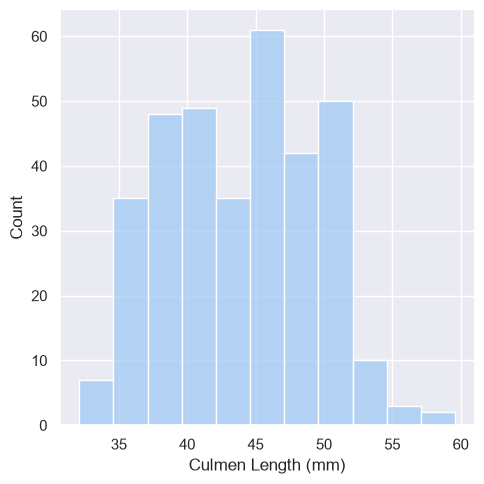

In [30]:
# for culmen length
sns.displot(kind='hist',data=df, x='Culmen Length (mm)')

From the above hist plot we can see the most common culmen length lies between 45-50 and list is between 55-60

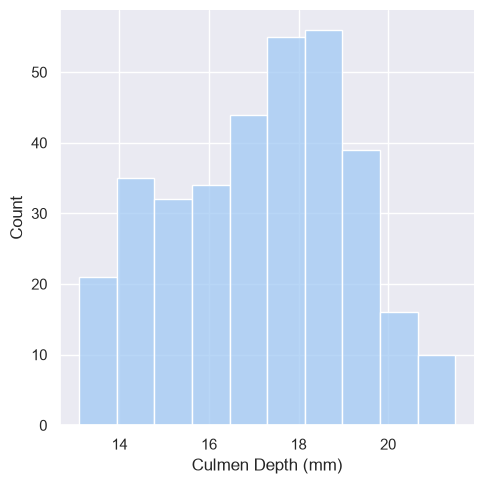

In [31]:
# for culmen depth
sns.displot(kind='hist',data=df, x='Culmen Depth (mm)')

from above graph we can see mostly culmen depth lies between 16-20

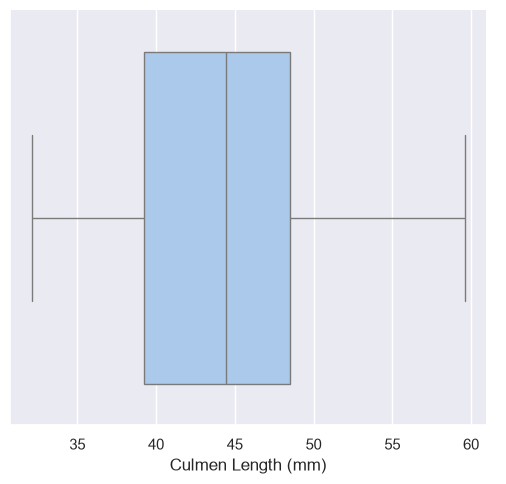

In [32]:
# boxplot
sns.catplot(kind='box',data=df, x='Culmen Length (mm)')

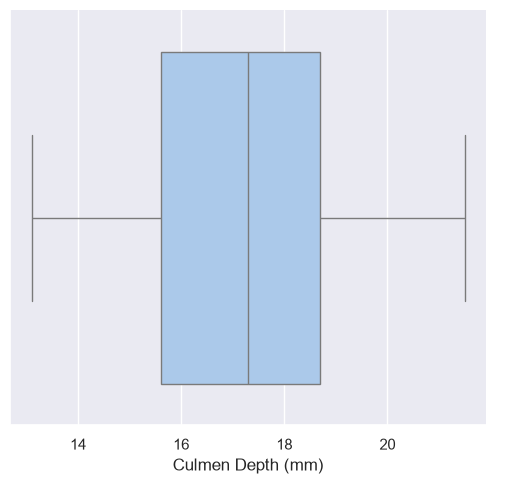

In [34]:
sns.catplot(kind='box',data=df, x='Culmen Depth (mm)')

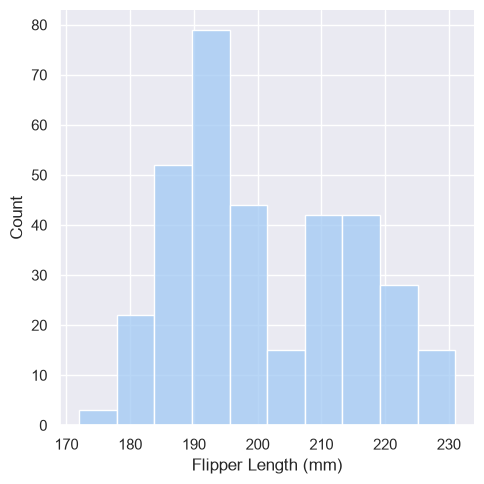

In [35]:
# for Flipper lenght
sns.displot(kind='hist',data=df, x='Flipper Length (mm)')

We can see from above graph most flipper length lies between 185-200mm

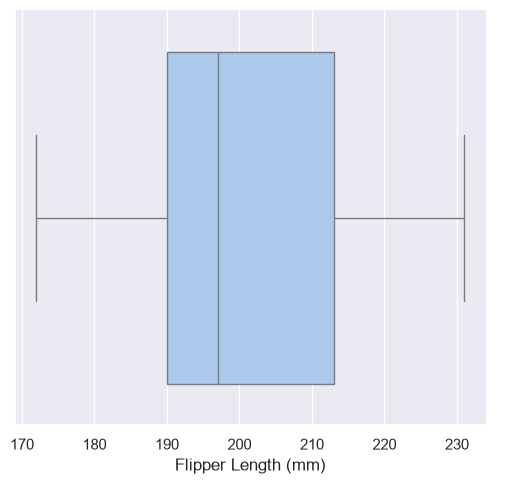

In [37]:
sns.catplot(kind='box',data=df, x='Flipper Length (mm)')

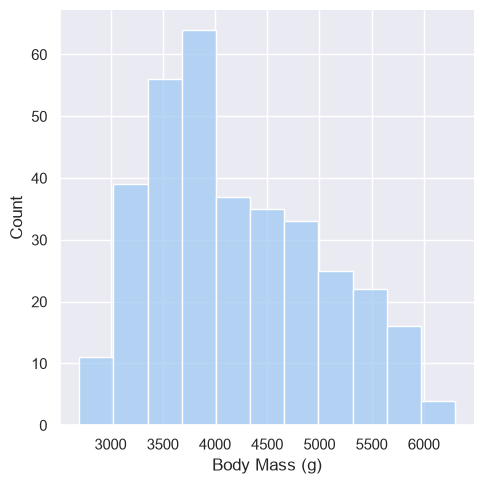

In [38]:
# For body mass
sns.displot(kind='hist',data=df, x='Body Mass (g)')

mostly bodymass is lie between 3500-4000g

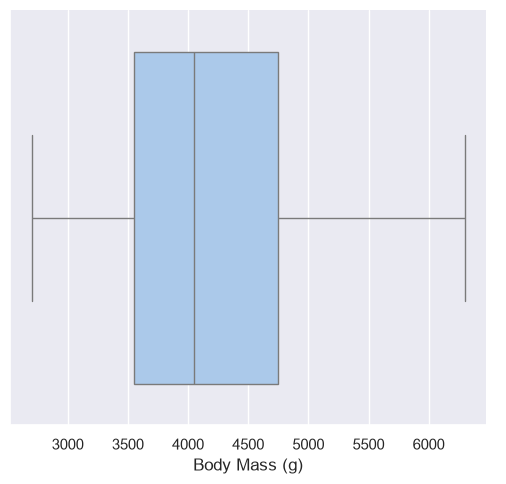

In [39]:
sns.catplot(kind='box',data=df, x='Body Mass (g)')

Frequency graphs for categorical features

([0, 1, 2],
 [Text(0, 0, 'Adelie Penguin (Pygoscelis adeliae)'),
  Text(1, 0, 'Chinstrap penguin (Pygoscelis antarctica)'),
  Text(2, 0, 'Gentoo penguin (Pygoscelis papua)')])

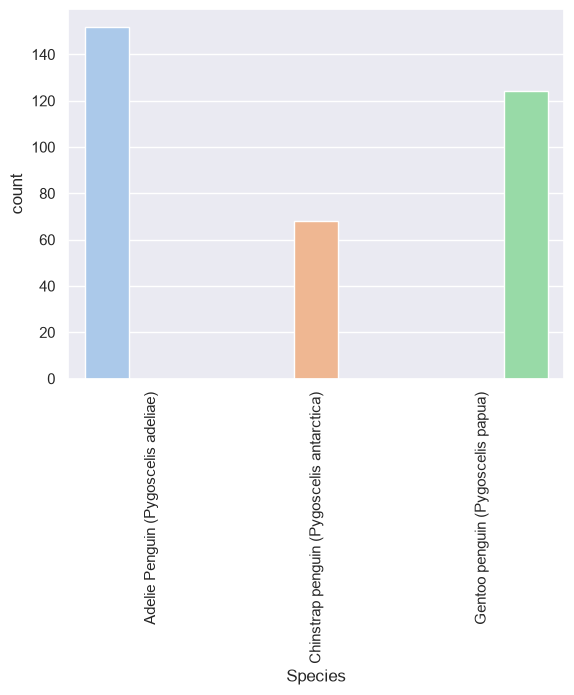

In [49]:
sns.countplot(data=df,x='Species',hue='Species')
plt.xticks(rotation=90)

<Axes: xlabel='Island', ylabel='count'>

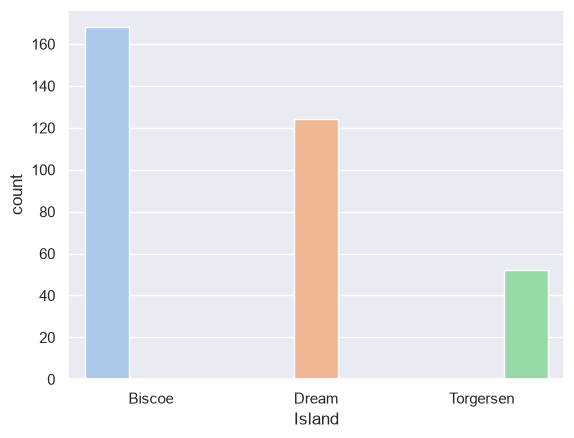

In [50]:
sns.countplot(data=df,x='Island',hue='Island')

<Axes: xlabel='Region', ylabel='count'>

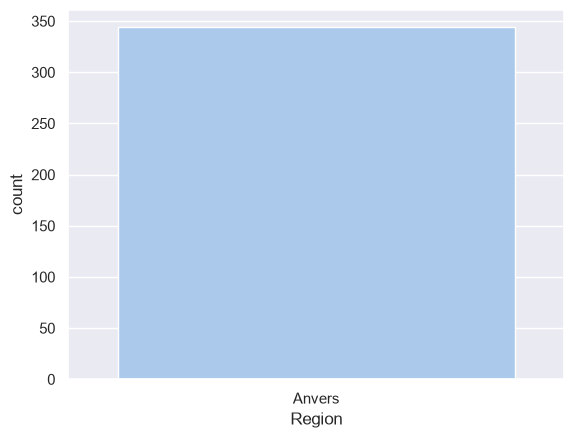

In [51]:
sns.countplot(data=df,x='Region',hue='Region')

<Axes: xlabel='Sex', ylabel='count'>

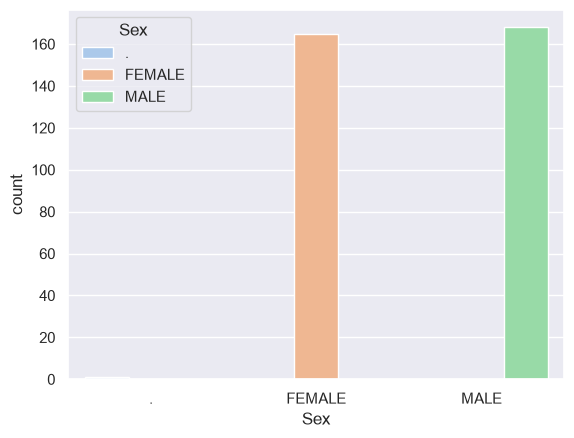

In [52]:
sns.countplot(data=df,x='Sex',hue='Sex')

In [54]:
df['Sex'].value_counts()

Sex
MALE      168
FEMALE    165
.           1
Name: count, dtype: int64

<Axes: xlabel='Clutch Completion', ylabel='count'>

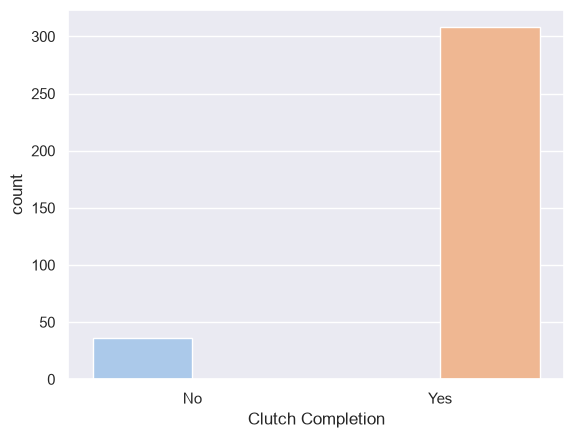

In [53]:
sns.countplot(data=df,x='Clutch Completion',hue='Clutch Completion')

* Q. Which Species is most common?
    - A: Adelie penguin

* Q. Which Island most species found?
    - A: Biscoe Island contains the highest number of penguin observations in the dataset.

* Q. How many penguins has Clutch Completion is yes?
    - A: approx. 300

* Q. Male vs Female count?
    - A: Male: 168 and Female: 165

2. Bivariate Analysis

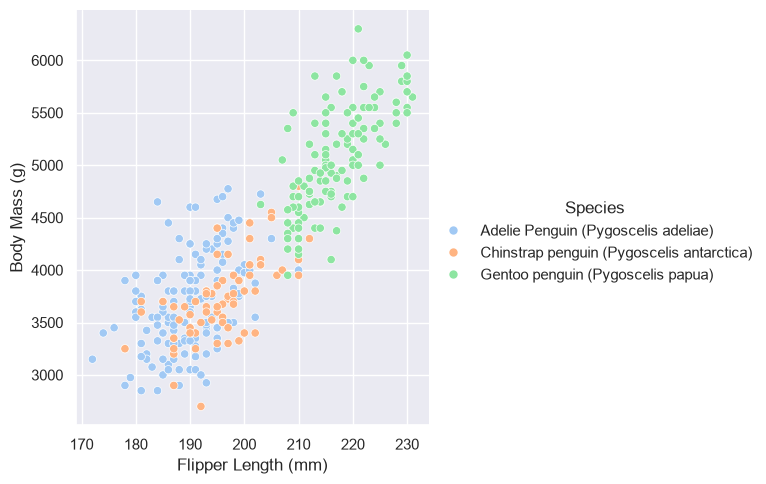

In [55]:
# Numerical vs Numerical
sns.relplot(
    x="Flipper Length (mm)",
    y="Body Mass (g)",
    hue="Species",
    data=df,
    kind='scatter'
)

* Q. Does body mass increase with flipper length?
    - A: Yes, significantly we can see that increasing flipper length is linearly increasing the body mass also.

* Q. Are there distinct species clusters?
    - A: yes, Adelie are slightly less flipper length and bodymass, chinstrap aare medium flipper length and bodymass, while, Gentoo has long flipper length and heavy bodymass.

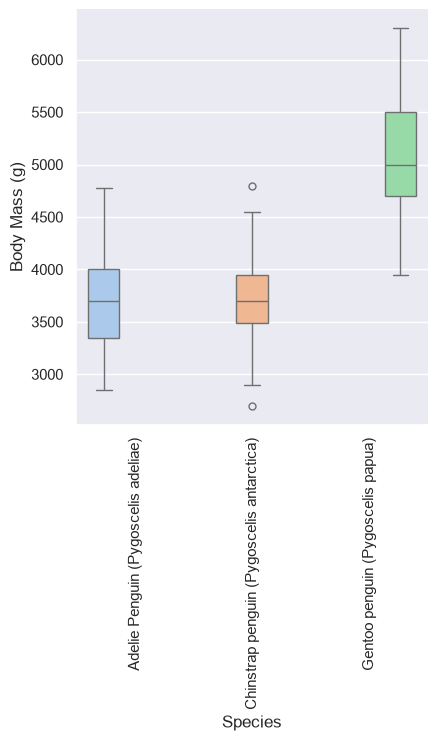

In [57]:
# categorical vs Numerical
sns.catplot(
    x="Species",
    y="Body Mass (g)",
    data=df,
    kind='box',
    hue='Species'
)
plt.xticks(rotation=90)
plt.show()

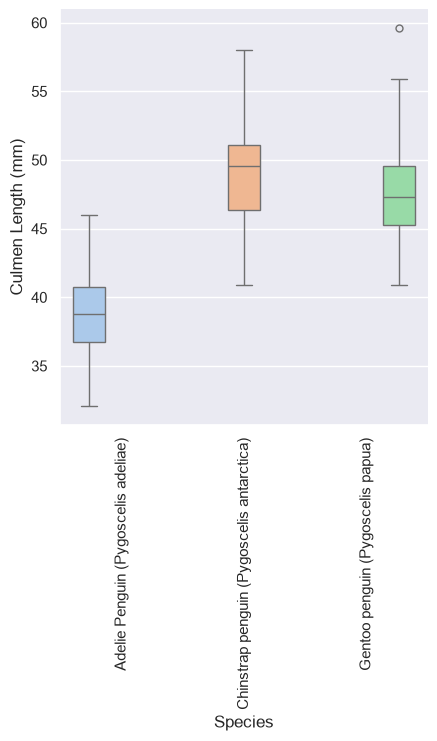

In [58]:
# categorical vs Numerical
sns.catplot(
    x="Species",
    y="Culmen Length (mm)",
    data=df,
    kind='box',
    hue='Species'
)
plt.xticks(rotation=90)
plt.show()

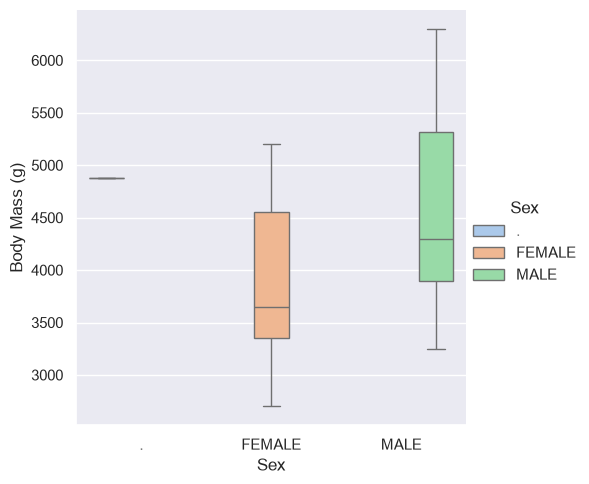

In [59]:
# categorical vs Numerical
sns.catplot(
    x="Sex",
    y="Body Mass (g)",
    data=df,
    kind='box',
    hue='Sex'
)
plt.show()

* Q.Which species is heaviest?
    - A: Gentoo penguins are significantly heaviest among all three.
* Q.Which species has the longest beak?
    - A: Chinstrap penguins have the longest average culmen (beak) length among the three species.
* Q.Do males weigh more than females?
    - A: Male penguins have a higher average body mass than female penguins across the dataset.

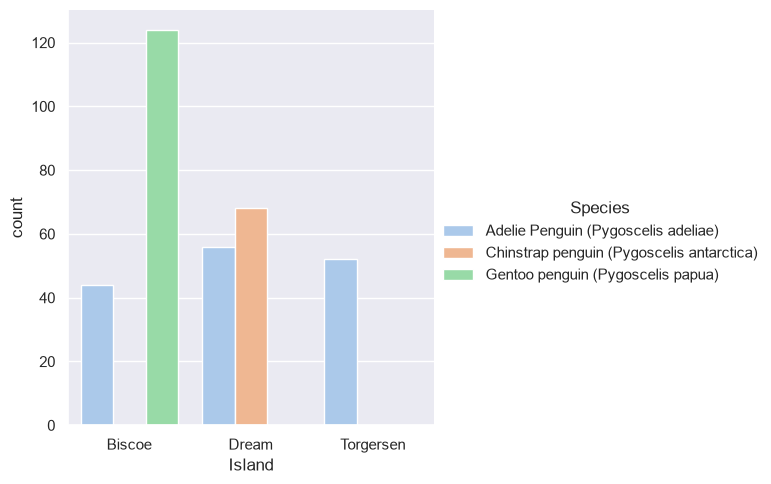

In [60]:
# Categorical vs Categorical
sns.catplot(
    x="Island",
    hue="Species",
    data=df,
    kind='count'
)

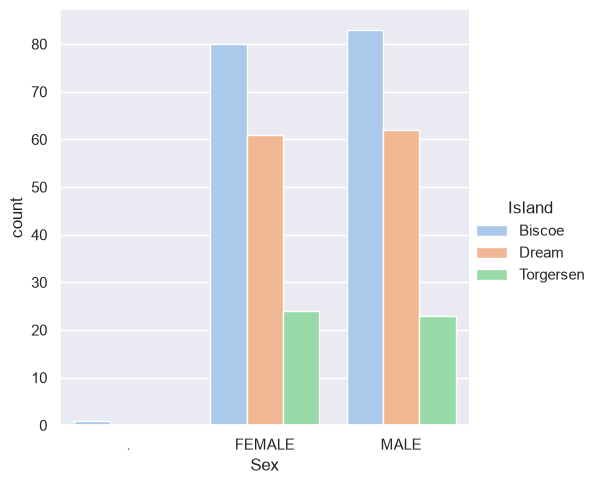

In [63]:
# Categorical vs Categorical
sns.catplot(
    x="Sex",
    hue="Island",
    data=df,
    kind='count'
)

* Q. Which species live on which islands?
    - A: Adelie lives on all three, Chinstrap lives only on "Dream Island", Gentoo lives only on "Biscoe Island".

* Q. Is each species associated with a particular island?
    - A: Yes, Except Adelie, Chinstrap only found on "Dream Island", and Gentoo only found on "Biscoe Island".
    
* Q. Which Gender lives more on which Island?
    - A: Male Sex is sligthly more on Biscoe than female sex, and for other islands they are almost same.

3. Multivariate Analysis

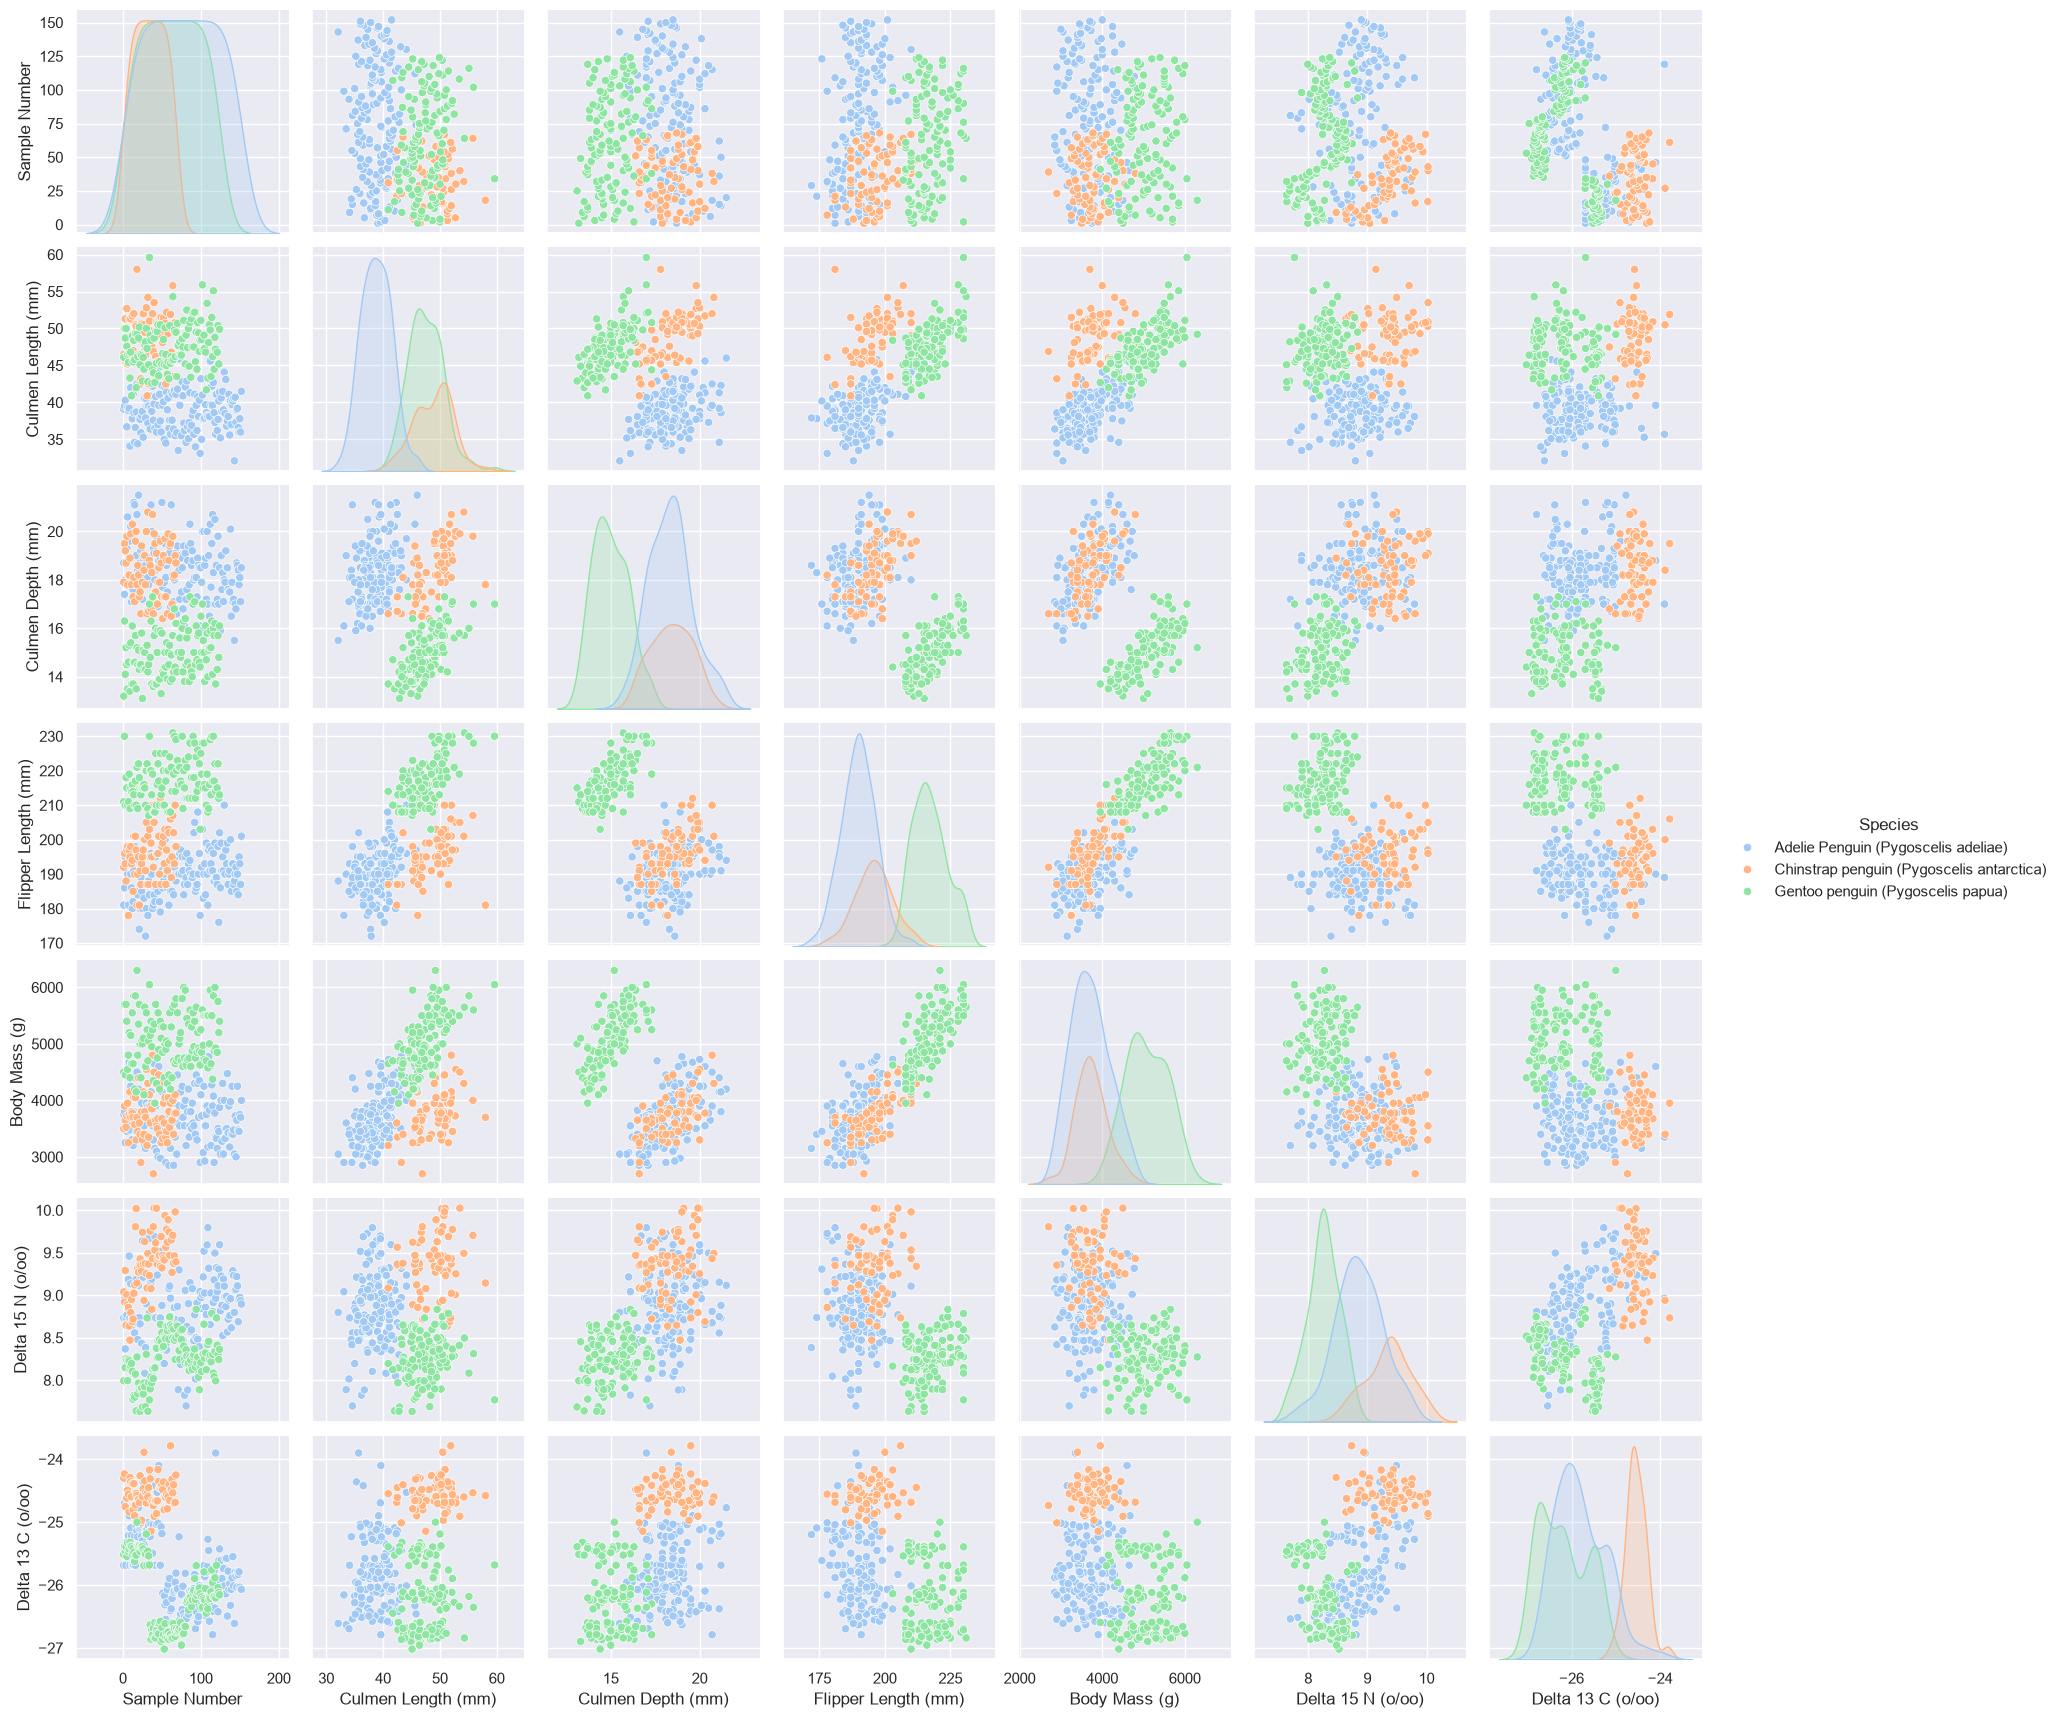

In [64]:
sns.pairplot(
    df,
    hue="Species"
)

In [65]:
df['Species'].value_counts()

Species
Adelie Penguin (Pygoscelis adeliae)          152
Gentoo penguin (Pygoscelis papua)            124
Chinstrap penguin (Pygoscelis antarctica)     68
Name: count, dtype: int64

<Axes: >

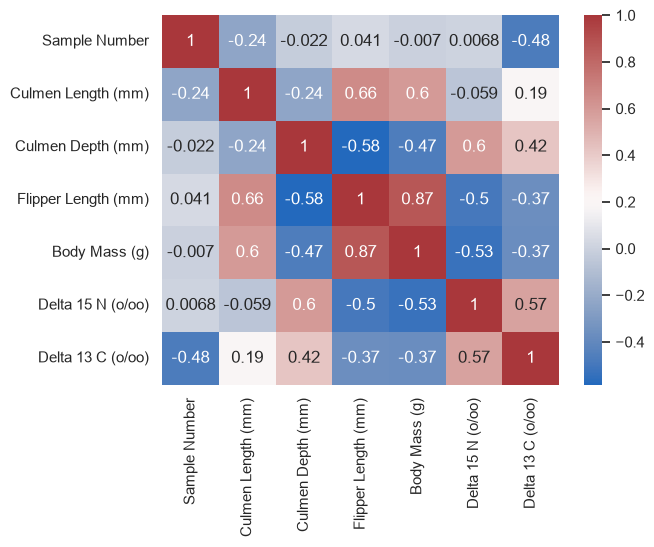

In [71]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='vlag')

heatmap observations:
1. Flipper length shows a moderate positive correlation with culmen length.
2. Flipper length and body mass exhibit a strong positive correlation, indicating that penguins with longer flippers tend to be heavier.
3. Delta 13C and culmen depth show a slightly moderate correlation.

### Key Findings:
- Adelie is the most frequently observed species.
- Gentoo penguins are the heaviest and have the longest flippers.
- Chinstrap penguins have the longest average culmen length.
- Body mass is strongly positively correlated with flipper length.
- Species are distributed differently across islands: Adelie occurs on all three islands, while Chinstrap is confined to Dream Island and Gentoo to Biscoe Island.
- Male penguins tend to have a higher average body mass than females.